# Analyse Exploratoire

### Import des modules

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 

### Analyse Exploratoire

1) Chargement et présentation des données

In [5]:
building_consumption = pd.read_csv("2016_Building_Energy_Benchmarking.csv")

In [6]:
# On regarde comment un batiment est défini dans ce jeu de données 
building_consumption.head()

,OSEBuildingID,DataYear,BuildingType,PrimaryPropertyType,PropertyName,Address,City,State,ZipCode,TaxParcelIdentificationNumber,...,Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),DefaultData,Comments,ComplianceStatus,Outlier,TotalGHGEmissions,GHGEmissionsIntensity
0,1,2016,NonResidential,Hotel,Mayflower park hotel,405 Olive way,Seattle,WA,98101.0,0659000030,...,1.156514e+06,3946027.0,12764.52930,1276453.0,False,NaN,Compliant,NaN,249.98,2.83
1,2,2016,NonResidential,Hotel,Paramount Hotel,724 Pine street,Seattle,WA,98101.0,0659000220,...,9.504252e+05,3242851.0,51450.81641,5145082.0,False,NaN,Compliant,NaN,295.86,2.86
2,3,2016,NonResidential,Hotel,5673-The Westin Seattle,1900 5th Avenue,Seattle,WA,98101.0,0659000475,...,1.451544e+07,49526664.0,14938.00000,1493800.0,False,NaN,Compliant,NaN,2089.28,2.19
3,5,2016,NonResidential,Hotel,HOTEL MAX,620 STEWART ST,Seattle,WA,98101.0,0659000640,...,8.115253e+05,2768924.0,18112.13086,1811213.0,False,NaN,Compliant,NaN,286.43,4.67
4,8,2016,NonResidential,Hotel,WARWICK SEATTLE HOTEL (ID8),401 LENORA ST,Seattle,WA,98121.0,0659000970,...,1.573449e+06,5368607.0,88039.98438,8803998.0,False,NaN,Compliant,NaN,505.01,2.88


In [7]:
# On regarde le nombre de valeurs manquantes par colonne ainsi que leur type 
building_consumption.info()

<class 'pandas.DataFrame'>
RangeIndex: 3376 entries, 0 to 3375
Data columns (total 46 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   OSEBuildingID                    3376 non-null   int64  
 1   DataYear                         3376 non-null   int64  
 2   BuildingType                     3376 non-null   str    
 3   PrimaryPropertyType              3376 non-null   str    
 4   PropertyName                     3376 non-null   str    
 5   Address                          3376 non-null   str    
 6   City                             3376 non-null   str    
 7   State                            3376 non-null   str    
 8   ZipCode                          3360 non-null   float64
 9   TaxParcelIdentificationNumber    3376 non-null   str    
 10  CouncilDistrictCode              3376 non-null   int64  
 11  Neighborhood                     3376 non-null   str    
 12  Latitude                       

2) Description des variables

In [ ]:
a) Description globale des variables (supposé)

On liste ici les différentes variables et leur signification (supposé) :

1. Identifiants et informations
- #1 - OSEBuildingID : Un identifiant unique attribué à chaque propriété couverte par l'ordonnance de Seattle.
- #2 - DataYear : Année civile de chaque enregistrement de données.
- #3 - BuildingType : Classification des types de bâtiments de haut niveau de la ville de Seattle (Non-résidentiel, Campus, familiale, etc.).
- #5 -  PropertyName : Nom du batiment
- #15 - YearBuilt : L'année de construction. Plus un bâtiment est vieux, plus son isolation est potentiellement datée.


2. Localisation (L'influence géographique)
- #6 - Address : Adresse du bien à Seattle.
- #7 - City : Ville (Seattle partout).
- #8 - State : Etat (Washington partout).
- #9 - Zip Code : Code postal (commence tous par 98).
- #10 - TaxParcelIdentificationNumber : Numéro d'identification de parcelle (PIN) du comté de King.
- #11 - CouncilDistrictCode : Code du district municipal (utile pour des politiques publiques).
- #12 - Neighborhood : Le quartier de Seattle.
- #13/14 - Latitude / Longitude : Coordonnées précises - permettent de voir s'il y a des "clusters" (zones) de forte consommation, en fonction d'une exposition potentielles à des phénomènes climatiques.


3. Informations Structurelles (Les caractéristiques physiques)
- #16 - NumberofBuildings : Le nombre de bâtiments sur la propriété (certains complexes ont plusieurs batiment).
- #17 - NumberofFloors : Le nombre d'étages 'habitales' (à partir du nouveau du sol ou au dessus).
- #18 - PropertyGFATotal : La surface totale (GFA - Gross Floor Area) brute et batiment et du stationnement en pieds carrés.
- #19 - PropertyGFAParking : Surface totale en pieds carrés de tous types de stationnement (entièrement fermé, partiellement fermé et ouvert), mais exclut les surface de batiment (plancher) non dédié au stationnement.
- #20 - PropertyGFABuilding(s) : Surface totale de plancher (en pieds carrés) entre les murs extérieurs d'un bâtiment. Elle comprend toutes les surfaces intérieures (locaux locatifs, parties communes, cages d'escalier, sous-sols, espaces de stockage, etc.), mais exclut le stationnement.

4. Typologie et Usage (L'activité humaine - les usages du batiment)
- #4 - PrimaryPropertyType : L'usage principal déclaré (Hôtel, Bureau, Entrepôt) pour le batiment.
- #21 - ListOfAllPropertyUseTypes : Liste des tous les usages réels occupé par le batiment (sous forme de lite séparé par une virgule).
- #22 - LargestPropertyUseType : Le type d'utilisation du bien le plus important en fonction de la surface brute du bâtiment. Autrement dit, L'usage réel qui occupe la plus grande surface.
- #23 - LargestPropertyUseTypeGFA (sf) : La surface exacte de cet usage principal (LargestPropertyUseType).
- #24 - SecondLargestPropertyUseType :  Le deuxième type d'utilisation de la propriété le plus important en fonction de la surface de plancher brute du bâtiment. Utile pour les bâtiments mixtes (ex: un immeuble de bureaux avec un restaurant au rez-de-chaussée).
- #25 - SecondLargestPropertyUseTypeGFA (sf) : La superficie brute en pieds carrés (sf) de ce second usage.
- #26 - ThirdLargestPropertyUseType :  Le troisième type d'utilisation de la propriété le plus important en fonction de la surface de plancher brute du bâtiment.
- #27 - ThirdLargestPropertyUseTypeGFA (sf) : La superficie brute en pieds carrés (sf) de ce troisème usage.

5. Indicateurs de consommations énergetiques (Cibles - targets potentielles)

    a. Indicateurs spécifiques (par type d'energie).

- #36 - SteamUse(kBtu) : La quantité annuelle de vapeur de réseau consommée par la propriété sur place, mesurée en milliers d'unités thermiques britanniques (kBtu).

- #37 - Electricity(kWh) : 	La quantité annuelle d'électricité consommée par la propriété sur place, y compris l'électricité achetée sur le réseau et produite par les systèmes renouvelables sur place, mesurée en kWh.
- #38 - Electricity(kBtu) : Cette même quantité, exprimé en kBtu.

- #39 - NaturalGas(therms) : La quantité annuelle de gaz naturel fourni par le service public et consommée par la propriété, mesurée en thermies.
- #40 - NaturalGas(kBtu) : Cette même quantité, exprimé en kBtu.

    b. Indicateurs globaux (tout type d'energie confondues).
   
- #34 - SiteEnergyUse(kBtu) : La quantité annuelle d'énergie consommée réellement par la propriété, toutes sources d'énergie confondues. Cible principale de cette étude. Elle est mesurée en milliers (kilos) de BTU British thermal unit. Ce chiffre correspond exactement à la somme des 3 consommations réelles énoncées précedemment : SteamUse(kBtu) + Electricity(kBtu) + NaturalGas(kBtu).
- #35 - SiteEnergyUseWN(kBtu) : Idem, mais Weather Normalized. Elle simule ce qu'aurait été la consommation si l'année avait eu des températures standards : "La consommation énergétique brute normalisée représente la consommation qu'aurait eue le bâtiment dans des conditions climatiques moyennes sur 30 ans".

- #30 - SiteEUI(kBtu/sf) : L'Intensité d'Usage Énergétique (Energy Use Intensity) du site. L'intensité énergétique du site (IES) correspond à la consommation énergétique totale du site d'un bâtiment divisée par sa surface brute. Cela permet de comparer un petit et un grand bâtiment sur une base égale. Elle est mesurée en kBtu par pied carrés (sf - square feet). 
- #31 - SiteEUIWN(kBtu/sf) : Idem, mais Weather Normalized : "L'énergie du site WN correspond à la consommation énergétique du site lors des 30 dernières années, dans des conditions météorologiques moyennes". Elle est mesurée en kBtu par pied carrés (sf - square feet).

- #32 - SourceEUI(kBtu/sf) : L'Intensité d'Usage Énergétique (Energy Use Intensity) de la source. L'intensité d'usage énergétique de la source (IES) correspond à la consommation énergétique d'un bâtiment à la source, divisée par sa surface brute. Contrairement au "Site", elle prend en compte l'énergie perdue lors de la production et du transport (très utile pour l'impact écologique global).
- #33 - SourceEUIWN(kBtu/sf) : Idem, mais Weather Normalized. "La consommation énergétique brute normalisée représente la consommation qu'aurait eue le bâtiment dans des conditions climatiques moyennes sur 30 ans'.

6. Indicateurs de Performance énergetiques
- #28 - YearsENERGYSTARCertified : Année d'attribution de l'ENERGYSTARScore (ci-dessous)
- #29 - ENERGYSTARScore :	L'EPA attribue une note de 1 à 100 qui évalue la performance énergétique globale d'un bâtiment, en se basant sur des données nationales afin de neutraliser les différences liées au climat, à l'usage du bâtiment et à son exploitation (100 est le meilleur).Un score de 50 signifie que le bâtiment est dans la moyenne nationale pour son type.

7. Emissions de Gaz à Effet de Serre
- TotalGHGEmissions : Les émissions totales de gaz à effet de serre (en tonnes métriques d'équivalent CO2). Cela inclut le dioxyde de carbone, le méthane et l'oxyde nitreux, rejetées dans l'atmosphère du fait de la consommation d'énergie du bâtiment.
- GHGEmissionsIntensity : Les émissions rapportées à la surface brute du batiment (en pieds carrés).

8. Autre
- #41 - DefaultData : Indicateur (vrai/faux) précisant si des données par défaut ont été utilisées à la place de mesures réelles.
- #42 - Comments : Commentaires libres ajoutés lors du relevé.
- #43 - ComplianceStatus : Statut de conformité du bâtiment vis-à-vis de la loi sur le benchmarking  (Compliant/Nom-Compliant/Error - Correct Default Data/Missing Data). Peut-être utilse pour la prédiction de la consommation d'energie (dans le but de discrediter certains batiments). 
- #44 - Outlier : Indicateur signalant si le bâtiment a été identifié comme une valeur aberrante (par la ville).

b) Statistiques sur les variables quantitatives

On donnera les éléments principales de ces variables grâce à la fonction describe(). Cette fonction donne les informations suivantes : 
- nombre d'occurences (ou valeurs présentes), sur 3376 lignes au total.
- la moyenne
- l'écart type (la moyenne des écarts à la moyenne)
- la valeur minimum
- les écarts interquartiles (quel est la valeur pour laquelle 25% des "effectifs" ont en dessous de cette valeur, 50% des effectifs, etc, etc).
- la valeur maximum

In [12]:
# ============================================================
# DESCRIPTION DES VARIABLES QUANTITATIVES
# ============================================================

cols_quantitatives = building_consumption.select_dtypes(include=['number']).columns.tolist()
print(f"{len(cols_quantitatives)} colonnes numériques\n")

building_consumption[cols_quantitatives].describe().T.round(2)

30 colonnes numériques



,count,mean,std,min,25%,50%,75%,max
OSEBuildingID,3376.0,21208.99,12223.76,1.00,19990.75,23112.00,25994.25,5.022600e+04
DataYear,3376.0,2016.00,0.00,2016.00,2016.00,2016.00,2016.00,2.016000e+03
ZipCode,3360.0,98116.95,18.62,98006.00,98105.00,98115.00,98122.00,9.827200e+04
CouncilDistrictCode,3376.0,4.44,2.12,1.00,3.00,4.00,7.00,7.000000e+00
Latitude,3376.0,47.62,0.05,47.50,47.60,47.62,47.66,4.773000e+01
Longitude,3376.0,-122.33,0.03,-122.41,-122.35,-122.33,-122.32,-1.222200e+02
YearBuilt,3376.0,1968.57,33.09,1900.00,1948.00,1975.00,1997.00,2.015000e+03
NumberofBuildings,3368.0,1.11,2.11,0.00,1.00,1.00,1.00,1.110000e+02
NumberofFloors,3376.0,4.71,5.49,0.00,2.00,4.00,5.00,9.900000e+01
PropertyGFATotal,3376.0,94833.54,218837.61,11285.00,28487.00,44175.00,90992.00,9.320156e+06


c) Statistiques des variables qualitatives

On décrit chaque variables en lisant ses modalités et le nombre d'occurences de chacune de ses modalités

In [74]:
# ============================================================
# DESCRIPTION DES VARIABLES QUALITATIVES (CATÉGORIELLES)
# ============================================================

cols_qualitatives = building_consumption.select_dtypes(include=['object', 'str']).columns.tolist()
print(f"{len(cols_qualitatives)} colonnes catégorielles\n")

SEUIL_PCT = 5  # n'affiche que les modalités >= 5% de l'effectif

for col in cols_qualitatives:
    n_unique = building_consumption[col].nunique()
    counts = building_consumption[col].value_counts()
    top = counts[counts / len(building_consumption) * 100 >= SEUIL_PCT]
    
    print(f"── {col} ({n_unique} valeurs uniques)")
    for val, count in top.items():
        pct = count / len(building_consumption) * 100
        print(f"   {val} : {count} occurrences ({pct:.1f}%)")
    if len(top) == 0:
        print("   (aucune modalité ne dépasse le seuil)")
    print()

#Cette partie permettant de lister les 3 modalités les plus représentées en terme d'occurence de
#chacun des colonnes qualitatives 

'''
for col in cols_qualitatives:
    n_unique = building_consumption[col].nunique()
    top3 = building_consumption[col].value_counts().head(3).to_dict()
    #items = building_consumption[col].value_counts().to_dict()
    print(f"── {col} ({n_unique} valeurs uniques)")
    for val, count in top3.items():
    #for val, count in items.items():
        print(f"   {val!r:<45} {count} occurrences")
    print()

'''

15 colonnes catégorielles

── BuildingType (8 valeurs uniques)
   NonResidential : 1460 occurrences (43.2%)
   Multifamily LR (1-4) : 1018 occurrences (30.2%)
   Multifamily MR (5-9) : 580 occurrences (17.2%)

── PrimaryPropertyType (24 valeurs uniques)
   Low-Rise Multifamily : 987 occurrences (29.2%)
   Mid-Rise Multifamily : 564 occurrences (16.7%)
   Small- and Mid-Sized Office : 293 occurrences (8.7%)
   Other : 256 occurrences (7.6%)
   Warehouse : 187 occurrences (5.5%)
   Large Office : 173 occurrences (5.1%)

── PropertyName (3362 valeurs uniques)
   (aucune modalité ne dépasse le seuil)

── Address (3354 valeurs uniques)
   (aucune modalité ne dépasse le seuil)

── City (1 valeurs uniques)
   Seattle : 3376 occurrences (100.0%)

── State (1 valeurs uniques)
   WA : 3376 occurrences (100.0%)

── TaxParcelIdentificationNumber (3268 valeurs uniques)
   (aucune modalité ne dépasse le seuil)

── Neighborhood (19 valeurs uniques)
   DOWNTOWN : 573 occurrences (17.0%)
   EAST : 453 

'\nfor col in cols_qualitatives:\n    n_unique = building_consumption[col].nunique()\n    top3 = building_consumption[col].value_counts().head(3).to_dict()\n    #items = building_consumption[col].value_counts().to_dict()\n    print(f"── {col} ({n_unique} valeurs uniques)")\n    for val, count in top3.items():\n    #for val, count in items.items():\n        print(f"   {val!r:<45} {count} occurrences")\n    print()\n\n'

3) Filtrage des lignes et des colonnes

In [ ]:
a. 

On va désormais filtrer une partie des lignes en supprimant les batiments qui sont résidentiels. En effet l'étude s'intéresse aux batiments non résidentiels donc pas de raisons de conserver les autres. Pour faire cela, on va déjà determiner les types de batiment et par extension, ceux qui ne concernent pas des batiments résidentiels. 

In [26]:
colums_BuildingType = building_consumption['BuildingType'].unique()
for c in colums_BuildingType:
        print(c)

NonResidential
Nonresidential COS
Multifamily MR (5-9)
SPS-District K-12
Campus
Multifamily LR (1-4)
Multifamily HR (10+)
Nonresidential WA


On peut statuer avec certitude que les modalités 'Multifamily LR (1-4)', 'Multifamily MR (5-9)' et 'Multifamily HR (10+)' concerne des batiments résidentiels, de par leurs noms explicites. Par conséquent, nous allons procéder à leur suppresssion dans le dataframe. Pour les autres nous ne sommes pas surs donc on va les garder pour l'instant.

In [32]:
# ============================================================
# FILTRAGE — Bâtiments non résidentiels uniquement
# ============================================================

len_before_filtering_1 = len(building_consumption)
print(f"Lignes initiales : {len_before_filtering_1}")

# On garde uniquement les bâtiments non destinés à l'habitation
# Les types Multifamily (LR/MR/HR) sont des immeubles résidentiels → hors scope de l'étude
types_to_exclude = ['Multifamily LR (1-4)', 'Multifamily MR (5-9)', 'Multifamily HR (10+)']

non_residentials_building_consumption = building_consumption[~building_consumption['BuildingType'].isin(types_to_exclude)]

len_after_filtering_1 = len(non_residentials_building_consumption)
print(f"Après filtrage résidentiel : {len_after_filtering_1} bâtiments")


Lignes initiales : 3376
Après filtrage résidentiel : 1668 bâtiments


In [30]:
colums_BuildingType = non_residentials_building_consumption['BuildingType'].unique()
for c in colums_BuildingType:
        print(c)

NonResidential
Nonresidential COS
SPS-District K-12
Campus
Nonresidential WA


* Identifier les colonnes qui peuvent aider à repérer des bâtiments aberrants ou peu pertinents.

Très clairement la colonne 'Outlier' permet de déterminer des batiments abérrants car ce terme signie 'Valeur aberrante' en anglais. On va donc commencer par procéder à la suppression de ces lignes.

In [34]:
len_before_filtering_2 = len(non_residentials_building_consumption)
print(f"Lignes initiales : {len_before_filtering_2}")
filtered_2_building_consumption = non_residentials_building_consumption[non_residentials_building_consumption['Outlier'].isna()]
len_after_filtering_2 = len(filtered_2_building_consumption)
print(f"Après deuxième filtrage (outlier) : {len_after_filtering_2}")

Lignes initiales : 1668
Après deuxième filtrage (outlier) : 1651


De même, l'objectif principal de ce projet est de détermier la consommation des batiments en énergie. Cette consommation est défini (en partie) par la colonne SiteEnergyUse(kBtu). Or une consommation ne peut pas être nulle ou négative. Par conséquent on supprimer les lignes où c'est le cas. 

In [44]:
# Suppression des consommations nulles ou négatives (incohérent pour un bâtiment actif)
print(f"Lignes initiales : {len_before_filtering_2}")
filtered_3_building_consumption = filtered_2_building_consumption[filtered_2_building_consumption['SiteEnergyUse(kBtu)'] > 0]
len_after_filtering_3 = len(filtered_3_building_consumption)
print(f"Après troisième filtrage (outlier) : {len_after_filtering_3}")

Lignes initiales : 1668
Après troisième filtrage (outlier) : 1633


On va désormais regarder le nombre de valeurs manquantes par colonne :

In [45]:
# Valeurs manquantes par colonne
missing = pd.DataFrame({
    'nb_manquantes': filtered_2_building_consumption.isnull().sum(),
    'taux (%) de valeurs manquantes': (filtered_2_building_consumption.isnull().sum() / len(filtered_2_building_consumption) * 100).round(2)
})
missing = missing.sort_values('taux (%) de valeurs manquantes', ascending=False)
print(missing)

                                 nb_manquantes  taux (%) de valeurs manquantes
Outlier                                   1651                          100.00
Comments                                  1651                          100.00
YearsENERGYSTARCertified                  1553                           94.06
ThirdLargestPropertyUseType               1300                           78.74
ThirdLargestPropertyUseTypeGFA            1300                           78.74
SecondLargestPropertyUseType               803                           48.64
SecondLargestPropertyUseTypeGFA            803                           48.64
ENERGYSTARScore                            568                           34.40
ZipCode                                     16                            0.97
LargestPropertyUseType                       6                            0.36
LargestPropertyUseTypeGFA                    6                            0.36
SiteEUI(kBtu/sf)                             3      

En fonction de ces résultats, on va supprimer 3 colonnes qui n'apportent aucune information (ou quasiment pas) :
- Outlier
- Comments
- YearsENERGYSTARCertified

In [ ]:
# Liste des colonnes à supprimer
cols_to_drop = [
    'Comments', 
    'YearsENERGYSTARCertified', 
    'Outlier'
]

filtered_4_building_consumption = filtered_3_building_consumption.drop(columns=cols_to_drop)
print(f"Nombre de colonnes restantes : {filtered_4_building_consumption.shape[1]}")
filtered_4_building_consumption.head()

On aurait également pu supprimer d'autres colonnes car elles ne présente aucune variance dans la mesure où elles ont la même valeur partout :
- DataYear : 2016 partout.
- City : Seattle partout.
- State : WA (washington) partout.

Nous allons en profiter pour le faire dans le cadre de ce projet afin d'alleger le modèle de prédiction.

In [48]:
# Liste des colonnes à supprimer
cols_to_drop = [
    'DataYear', 
    'City', 
    'State'
]

filtered_5_building_consumption = filtered_4_building_consumption.drop(columns=cols_to_drop)
print(f"Nombre de colonnes restantes : {filtered_5_building_consumption.shape[1]}")
filtered_5_building_consumption.head()

Nombre de colonnes restantes : 40


,OSEBuildingID,BuildingType,PrimaryPropertyType,PropertyName,Address,ZipCode,TaxParcelIdentificationNumber,CouncilDistrictCode,Neighborhood,Latitude,...,SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),DefaultData,ComplianceStatus,TotalGHGEmissions,GHGEmissionsIntensity
0,1,NonResidential,Hotel,Mayflower park hotel,405 Olive way,98101.0,0659000030,7,DOWNTOWN,47.61220,...,7456910.0,2003882.00,1.156514e+06,3946027.0,12764.52930,1276453.0,False,Compliant,249.98,2.83
1,2,NonResidential,Hotel,Paramount Hotel,724 Pine street,98101.0,0659000220,7,DOWNTOWN,47.61317,...,8664479.0,0.00,9.504252e+05,3242851.0,51450.81641,5145082.0,False,Compliant,295.86,2.86
2,3,NonResidential,Hotel,5673-The Westin Seattle,1900 5th Avenue,98101.0,0659000475,7,DOWNTOWN,47.61393,...,73937112.0,21566554.00,1.451544e+07,49526664.0,14938.00000,1493800.0,False,Compliant,2089.28,2.19
3,5,NonResidential,Hotel,HOTEL MAX,620 STEWART ST,98101.0,0659000640,7,DOWNTOWN,47.61412,...,6946800.5,2214446.25,8.115253e+05,2768924.0,18112.13086,1811213.0,False,Compliant,286.43,4.67
4,8,NonResidential,Hotel,WARWICK SEATTLE HOTEL (ID8),401 LENORA ST,98121.0,0659000970,7,DOWNTOWN,47.61375,...,14656503.0,0.00,1.573449e+06,5368607.0,88039.98438,8803998.0,False,Compliant,505.01,2.88


On va désormais s'attarder à decrire (grâce à la méthode describe) les variables qui semblent les plus importantes.

In [54]:
important_cols = ['YearBuilt', 'PropertyGFATotal', 'NumberofFloors', 'SiteEnergyUse(kBtu)','TotalGHGEmissions']
filtered_5_building_consumption[important_cols].describe()

,YearBuilt,PropertyGFATotal,NumberofFloors,SiteEnergyUse(kBtu),TotalGHGEmissions
count,1633.000000,1.633000e+03,1633.000000,1.633000e+03,1633.000000
mean,1962.064911,1.192045e+05,4.157379,8.558079e+06,187.839437
std,32.706950,2.986849e+05,6.625049,3.051231e+07,759.161384
min,1900.000000,1.128500e+04,0.000000,5.713320e+04,-0.800000
25%,1930.000000,2.940000e+04,1.000000,1.268459e+06,20.900000
50%,1966.000000,4.924900e+04,2.000000,2.619088e+06,50.320000
75%,1989.000000,1.060000e+05,4.000000,6.983736e+06,144.790000
max,2015.000000,9.320156e+06,99.000000,8.739237e+08,16870.980000


A ce stade du projet, on peut définir deux variables candidates pour le rôle de "target" :
-SiteEnergyUse(kBtu)
-TotalGHGEmissions
Ces deux variables semblent être corrélés.

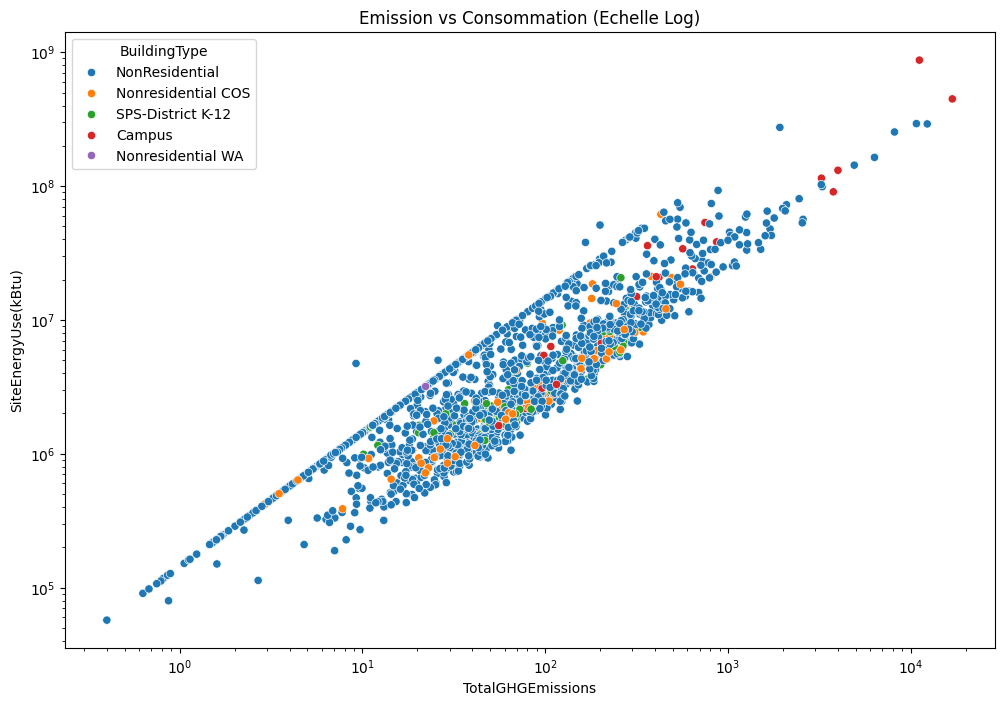

In [60]:
plt.figure(figsize=(12, 8))
sns.scatterplot(data=filtered_5_building_consumption, x='TotalGHGEmissions', y='SiteEnergyUse(kBtu)', hue='BuildingType')
plt.xscale('log')
plt.yscale('log')
plt.title('Emission vs Consommation (Echelle Log)')
plt.show()

Les deux variables sont effectivement très corrélés. Cependant, dans le cadre de notre étude, celle qui nous intéresse est clairement 'SiteEnergyUse(kBtu)' qui correspond à la consommation d'energie (en kBtu - kilobtus) de chaque batiment. Nous retiendrons donc 'SiteEnergyUse(kBtu)' comme variable target. 

Représentations graphiques de certaines variables

A. La distribution de la consommation (Target)

In [50]:
import numpy as np

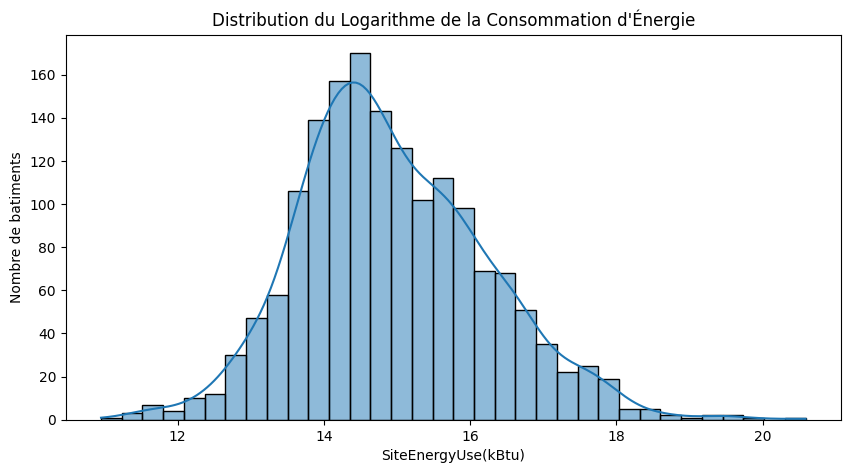

In [63]:
plt.figure(figsize=(10, 5))
sns.histplot(np.log1p(filtered_5_building_consumption['SiteEnergyUse(kBtu)']), kde=True)
plt.ylabel("Nombre de batiments")
#sns.histplot(filtered_5_building_consumption['SiteEnergyUse(kBtu)'], kde=True)
plt.title('Distribution du Logarithme de la Consommation d\'Énergie')
plt.show()

B. Relation entre Surface et Consommation par Type de bâtiment

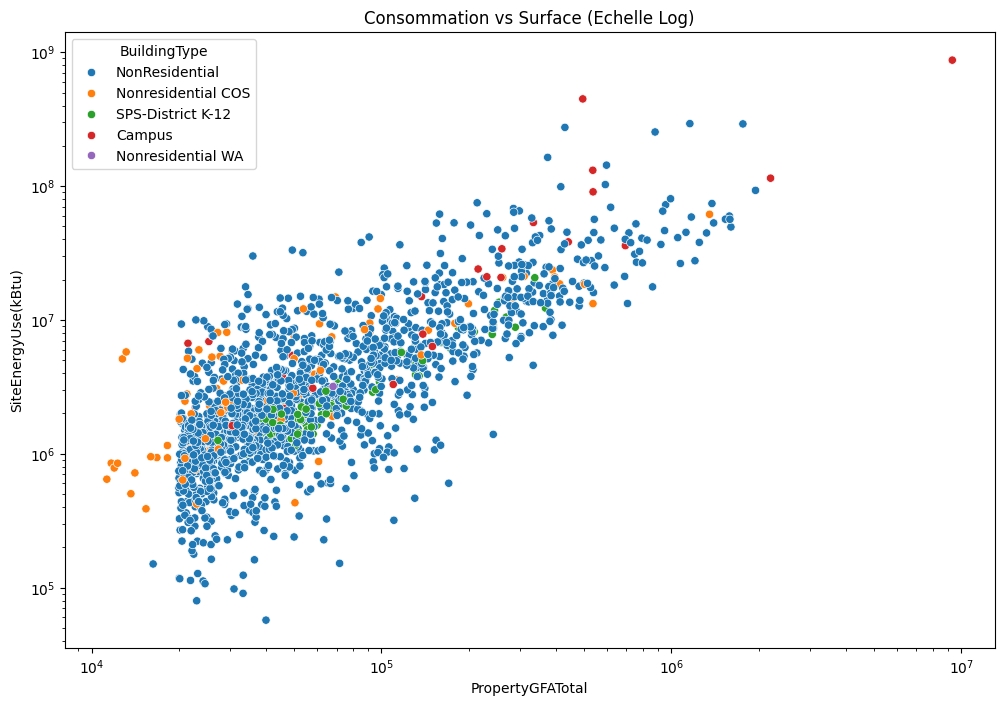

In [53]:
plt.figure(figsize=(12, 8))
sns.scatterplot(data=filtered_5_building_consumption, x='PropertyGFATotal', y='SiteEnergyUse(kBtu)', hue='BuildingType')
plt.xscale('log')
plt.yscale('log')
plt.title('Consommation vs Surface (Echelle Log)')
plt.show()

#### TERMINER L'ANALYSE EXPLORATOIRE 

A réaliser : 
- Une analyse descriptive des données, y compris une explication du sens des colonnes gardées, des arguments derrière la suppression de lignes ou de colonnes, des statistiques descriptives et des visualisations pertinentes.

# Modélisation 

### Import des modules 

In [ ]:
#Selection
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV, 
    cross_validate,
)
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error 
from sklearn.inspection import permutation_importance

#Preprocess
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler

#Modèles
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor


### Feature Engineering

A réaliser : Enrichir le jeu de données actuel avec de nouvelles features issues de celles existantes. 

In [ ]:
# CODE FEATURE ENGINEERING

### Préparation des features pour la modélisation

A réaliser :
* Si ce n'est pas déjà fait, supprimer toutes les colonnes peu pertinentes pour la modélisation.
* Tracer la distribution de la cible pour vous familiariser avec l'ordre de grandeur. En cas d'outliers, mettez en place une démarche pour les supprimer.
* Débarrassez-vous des features redondantes en utilisant une matrice de corrélation.
* Réalisez différents graphiques pour comprendre le lien entre vos features et la target (boxplots, scatterplots, pairplot si votre nombre de features numériques n'est pas très élevé).
*  Séparez votre jeu de données en un Pandas DataFrame X (ensemble de feautures) et Pandas Series y (votre target).
* Si vous avez des features catégorielles, il faut les encoder pour que votre modèle fonctionne.

In [ ]:
# CODE PREPARATION DES FEATURES

### Comparaison de différents modèles supervisés

A réaliser :
* Pour chaque algorithme que vous allez tester, vous devez :
    * Réaliser au préalable une séparation en jeu d'apprentissage et jeu de test via une validation croisée.
    * Si les features quantitatives que vous souhaitez utiliser ont des ordres de grandeur très différents les uns des autres, et que vous utilisez un algorithme de regression qui est sensible à cette différence, alors il faut réaliser un scaling (normalisation) de la donnée au préalable.
    * Entrainer le modèle sur le jeu de Train
    * Prédire la cible sur la donnée de test (nous appelons cette étape, l'inférence).
    * Calculer les métriques de performance R2, MAE et RMSE sur le jeu de train et de test.
    * Interpréter les résultats pour juger de la fiabilité de l'algorithme.
* Vous pouvez choisir par exemple de tester un modèle linéaire, un modèle à base d'arbres et un modèle de type SVM
* Déterminer le modèle le plus performant parmi ceux testés.

In [1]:
# CODE COMPARAISON DES MODELES

### Optimisation et interprétation du modèle

A réaliser :
* Reprennez le meilleur algorithme que vous avez sécurisé via l'étape précédente, et réalisez une GridSearch de petite taille sur au moins 3 hyperparamètres.
* Si le meilleur modèle fait partie de la famille des modèles à arbres (RandomForest, GradientBoosting) alors utilisez la fonctionnalité feature importance pour identifier les features les plus impactantes sur la performance du modèle. Sinon, utilisez la méthode Permutation Importance de sklearn. 

In [ ]:
# CODE OPTIMISATION ET INTERPRETATION DU MODELE